In [23]:
import pandas as pd
import numpy as np
import re

In [56]:
df = pd.read_csv('alanya_big_dataset.csv')

In [41]:
df.head()

,page,raw_text
0,1,140 000 € | Комнат:2+1 | Площадь:100 m² | Райо...
1,1,82 500 € | Комнат:1+1 | Площадь:50 m² | Район:...
2,1,283 500 € | Комнат: | Площадь:110 m² | Район: ...
3,1,157 500 € | Комнат:1+1 | Площадь:68 m² | Район...
4,1,86 000 € | Комнат:1+1 | Площадь:55 m² | Район:...


In [4]:
df['raw_text'][0]

'140 000 € | Комнат:2+1 | Площадь:100 m² | Район: Алания / Центр | До моря:550 м'

In [5]:
def extract_price(text):
    try:
        price_raw = text.split('€')[0].strip()
        price_clean = price_raw.replace(' ', '')
        return int(price_clean)
    except:
        return None

In [6]:
def extract_rooms(text):
    if isinstance(text, str):
        match = re.search(r'Комнат:(\d+\+\d+)', text)
        return match.group(1) if match else None
    return None

In [7]:
def extract_area(text):
    try:
        match = re.search(r'Площадь:(\d+)\s*m²', text)
        return int(match.group(1)) if match else None
    except:
        return None

In [8]:
def extract_district(text):
    if isinstance(text, str):
        match = re.search(r'Район:\s*Алания\s*/\s*([^|]+)', text)
        return match.group(1).strip() if match else None
    return None

In [9]:
def extract_distance(text):
    try:
        match = re.search(r'До моря:\s*([^|]+)', text)
        if not match:
            return None
        
        dist_str = match.group(1).lower().strip()
        
        if 'км' in dist_str:
            num = float(re.search(r'([\d,.]+)', dist_str).group(1).replace(',', '.'))
            return int(num * 1000)
        elif 'м' in dist_str:
            return int(re.search(r'(\d+)', dist_str).group(1))
        return None
    except:
        return None

In [57]:
df['price_€'] = df['raw_text'].apply(extract_price)

In [58]:
df['rooms'] = df['raw_text'].apply(extract_rooms)

In [59]:
df['area_sq_m'] = df['raw_text'].apply(extract_area)

In [60]:
df['district'] = df['raw_text'].apply(extract_district)

In [61]:
df['distance_to_sea_m'] = df['raw_text'].apply(extract_distance)

In [62]:
df.head()

,page,raw_text,price_€,rooms,area_sq_m,district,distance_to_sea_m
0,1,140 000 € | Комнат:2+1 | Площадь:100 m² | Райо...,140000.0,2+1,100.0,Центр,550.0
1,1,82 500 € | Комнат:1+1 | Площадь:50 m² | Район:...,82500.0,1+1,50.0,Центр,550.0
2,1,283 500 € | Комнат: | Площадь:110 m² | Район: ...,283500.0,None,110.0,Центр,NaN
3,1,157 500 € | Комнат:1+1 | Площадь:68 m² | Район...,157500.0,1+1,68.0,Махмутлар,600.0
4,1,86 000 € | Комнат:1+1 | Площадь:55 m² | Район:...,86000.0,1+1,55.0,Кестель,627.0


In [63]:
df.drop(['page', 'raw_text'], axis=1, inplace=True)

In [64]:
df_cl = df.copy()

In [65]:
df_cl.isna().sum()

price_€              2673
rooms                2200
area_sq_m            2291
district             2160
distance_to_sea_m    2236
dtype: int64

In [66]:
df_cl = df_cl.dropna(subset='price_€')

In [67]:
df_cl.isna().sum()

price_€                0
rooms                 37
area_sq_m            101
district               0
distance_to_sea_m     67
dtype: int64

In [69]:
df_cl = df_cl.dropna(subset='rooms')

In [75]:
df_cl['area_sq_m'] = df_cl['area_sq_m'].fillna(df_cl.groupby('rooms')['area_sq_m'].transform('median'))

In [78]:
df_cl.dropna(subset=['distance_to_sea_m'], inplace=True)

In [79]:
df_cl.isna().sum()

price_€              0
rooms                0
area_sq_m            0
district             0
distance_to_sea_m    0
dtype: int64

In [80]:
df_cl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 0 to 4311
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_€            1556 non-null   float64
 1   rooms              1556 non-null   object 
 2   area_sq_m          1556 non-null   float64
 3   district           1556 non-null   object 
 4   distance_to_sea_m  1556 non-null   float64
dtypes: float64(3), object(2)
memory usage: 72.9+ KB


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

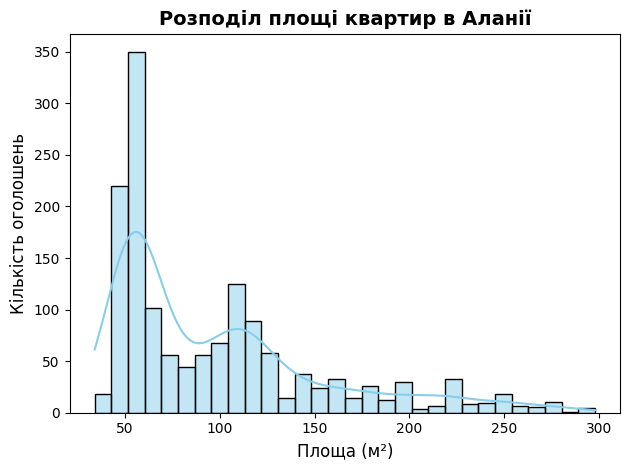

In [27]:
sns.histplot(data=df, x='area_sq_m', kde=True, color='skyblue', bins=30)

plt.title('Розподіл площі квартир в Аланії', fontsize=14, fontweight='bold')
plt.xlabel('Площа (м²)', fontsize=12)
plt.ylabel('Кількість оголошень', fontsize=12)
plt.tight_layout()
plt.show()

In [87]:
df_cl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 0 to 4311
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_€            1556 non-null   float64
 1   rooms              1556 non-null   object 
 2   area_sq_m          1556 non-null   float64
 3   district           1556 non-null   object 
 4   distance_to_sea_m  1556 non-null   float64
dtypes: float64(3), object(2)
memory usage: 72.9+ KB


In [88]:
df_cl.describe()

,price_€,area_sq_m,distance_to_sea_m
count,1.556000e+03,1556.000000,1556.000000
mean,2.297027e+05,112.669987,1022.321979
std,2.999205e+05,91.159543,997.675285
min,5.400000e+03,34.000000,0.000000
25%,1.073750e+05,55.000000,300.000000
50%,1.522500e+05,85.000000,700.000000
75%,2.300000e+05,130.000000,1500.000000
max,3.475000e+06,1115.000000,8000.000000


In [91]:
df_cl[df_cl['district'] == 'Инжекум']

,price_€,rooms,area_sq_m,district,distance_to_sea_m
3666,835000.0,10+1,600.0,Инжекум,3000.0


In [92]:
df_cl_upd = df_cl[df_cl['area_sq_m'] < 300]

In [93]:
df_cl_upd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1488 entries, 0 to 4310
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_€            1488 non-null   float64
 1   rooms              1488 non-null   object 
 2   area_sq_m          1488 non-null   float64
 3   district           1488 non-null   object 
 4   distance_to_sea_m  1488 non-null   float64
dtypes: float64(3), object(2)
memory usage: 69.8+ KB


In [95]:
df_cl_upd[df_cl_upd['rooms'] == '14+3']

,price_€,rooms,area_sq_m,district,distance_to_sea_m
3859,2860000.0,14+3,172.0,Центр,700.0


In [96]:
df_cl_upd = df_cl_upd.drop(index=3859)

In [103]:
df_cl_upd[(df_cl_upd['district'] == 'Джикджилли') & (df_cl_upd['price_€'] > 300000)]

,price_€,rooms,area_sq_m,district,distance_to_sea_m
707,378000.0,4+1,220.0,Джикджилли,1500.0
1873,346500.0,3+1,260.0,Джикджилли,1000.0
2049,310000.0,2+1,94.0,Джикджилли,1500.0
3264,560000.0,3+1,180.0,Джикджилли,750.0
3698,440000.0,3+1,150.0,Джикджилли,1900.0
4007,409000.0,2+1,110.0,Джикджилли,900.0


In [104]:
df_cl_upd['district'].value_counts()

district
Махмутлар     394
Оба           242
Центр         220
Авсаллар      134
Каргыджак     126
Кестель       101
Тосмур         65
Джикджилли     53
Газипаша       44
Паяллар        32
Демирташ       31
Конаклы        24
Тюрклер        16
Окурджалар      5
Name: count, dtype: int64

In [106]:
df_cl_upd['pr_per_sq_m'] = df_cl_upd['price_€'] / df_cl_upd['area_sq_m']

In [107]:
df_cl_upd.head()

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m
0,140000.0,2+1,100.0,Центр,550.0,1400.000000
1,82500.0,1+1,50.0,Центр,550.0,1650.000000
3,157500.0,1+1,68.0,Махмутлар,600.0,2316.176471
4,86000.0,1+1,55.0,Кестель,627.0,1563.636364
5,74000.0,1+1,55.0,Махмутлар,1500.0,1345.454545


In [108]:
df_cl_upd.describe()

,price_€,area_sq_m,distance_to_sea_m,pr_per_sq_m
count,1.487000e+03,1487.000000,1487.000000,1487.000000
mean,1.850059e+05,98.483524,966.827841,2012.582653
std,1.353677e+05,56.344184,942.159316,984.873683
min,5.400000e+03,34.000000,0.000000,105.882353
25%,1.050000e+05,55.000000,300.000000,1327.922078
50%,1.470000e+05,75.000000,627.000000,1800.000000
75%,2.132500e+05,120.000000,1450.000000,2447.712418
max,1.500000e+06,298.000000,8000.000000,11200.000000


In [110]:
df_cl_upd[df_cl_upd['pr_per_sq_m'] < 200]

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m
1207,5400.0,1+1,51.0,Авсаллар,900.0,105.882353


In [111]:
df_cl_upd = df_cl_upd.drop(index=1207)

In [112]:
df_cl_upd[df_cl_upd['pr_per_sq_m'] > 10000]

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m
2817,560000.0,1+1,50.0,Центр,700.0,11200.0


In [113]:
df_cl_upd = df_cl_upd.drop(index=2817)

In [123]:
df_cl_upd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1485 entries, 0 to 4310
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_€            1485 non-null   float64
 1   rooms              1485 non-null   object 
 2   area_sq_m          1485 non-null   float64
 3   district           1485 non-null   object 
 4   distance_to_sea_m  1485 non-null   float64
 5   pr_per_sq_m        1485 non-null   float64
dtypes: float64(4), object(2)
memory usage: 81.2+ KB


In [129]:
df_cl_upd[(df_cl_upd['area_sq_m'] < 70) & (df_cl_upd['pr_per_sq_m'] > 1500)]

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m
1,82500.0,1+1,50.0,Центр,550.0,1650.000000
3,157500.0,1+1,68.0,Махмутлар,600.0,2316.176471
4,86000.0,1+1,55.0,Кестель,627.0,1563.636364
6,77500.0,1+1,50.0,Каргыджак,200.0,1550.000000
20,91000.0,1+1,50.0,Оба,2700.0,1820.000000
...,...,...,...,...,...,...
4289,198500.0,1+1,65.0,Каргыджак,50.0,3053.846154
4292,99000.0,1+1,55.0,Авсаллар,700.0,1800.000000
4304,212000.0,1+1,58.0,Махмутлар,100.0,3655.172414
4308,165000.0,1+1,68.0,Оба,2000.0,2426.470588


In [130]:
df_cl_upd.describe()

,price_€,area_sq_m,distance_to_sea_m,pr_per_sq_m
count,1.485000e+03,1485.000000,1485.000000,1485.000000
mean,1.848744e+05,98.548148,967.052525,2007.679813
std,1.350281e+05,56.354575,942.766913,954.950483
min,4.650000e+04,34.000000,0.000000,669.696970
25%,1.050000e+05,55.000000,300.000000,1328.571429
50%,1.470000e+05,75.000000,625.000000,1800.000000
75%,2.120000e+05,120.000000,1500.000000,2444.444444
max,1.500000e+06,298.000000,8000.000000,8529.411765


In [131]:
df_cl_upd['class'] = 0

In [135]:
df_cl_upd.head()

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
0,140000.0,2+1,100.0,Центр,550.0,1400.000000,0
1,82500.0,1+1,50.0,Центр,550.0,1650.000000,0
3,157500.0,1+1,68.0,Махмутлар,600.0,2316.176471,0
4,86000.0,1+1,55.0,Кестель,627.0,1563.636364,0
5,74000.0,1+1,55.0,Махмутлар,1500.0,1345.454545,0


In [134]:
df_cl_upd['class'] = df_cl_upd['class'].astype(str)

In [137]:
conditions = [
    df_cl_upd['pr_per_sq_m'] <= 1300,
    (df_cl_upd['pr_per_sq_m'] > 1300) & (df_cl_upd['pr_per_sq_m'] <= 2500),
    df_cl_upd['pr_per_sq_m'] > 2500
]

In [138]:
classes = ['econom', 'comfort', 'lux']

In [140]:
df_cl_upd['class'] = np.select(conditions, classes, default=None)

In [141]:
df_cl_upd['class'].value_counts()

class
comfort    788
lux        349
econom     348
Name: count, dtype: int64

In [142]:
df_cl_upd.head()

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
0,140000.0,2+1,100.0,Центр,550.0,1400.000000,comfort
1,82500.0,1+1,50.0,Центр,550.0,1650.000000,comfort
3,157500.0,1+1,68.0,Махмутлар,600.0,2316.176471,comfort
4,86000.0,1+1,55.0,Кестель,627.0,1563.636364,comfort
5,74000.0,1+1,55.0,Махмутлар,1500.0,1345.454545,comfort


In [2]:
df = pd.read_csv('alanya_property.csv')

In [3]:
df.head()

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
0,140000.0,2+1,100.0,Центр,550.0,1400.000000,comfort
1,82500.0,1+1,50.0,Центр,550.0,1650.000000,comfort
2,157500.0,1+1,68.0,Махмутлар,600.0,2316.176471,comfort
3,86000.0,1+1,55.0,Кестель,627.0,1563.636364,comfort
4,74000.0,1+1,55.0,Махмутлар,1500.0,1345.454545,comfort


In [6]:
df['rooms'].value_counts()

rooms
1+1    728
2+1    457
3+1    188
4+1     74
3+2     12
5+1     11
1+0      9
4+2      5
2+2      1
Name: count, dtype: int64

In [5]:
df['rooms'] = df['rooms'].replace('0+1', '1+0')

In [15]:
df["district"] = df["district"].replace("Алания (Центр)", "Алания(Центр)")

In [16]:
df['district'].value_counts()

district
Махмутлар        394
Оба              242
Алания(Центр)    219
Авсаллар         133
Каргыджак        126
Кестель          101
Тосмур            65
Джикджилли        53
Газипаша          44
Паяллар           32
Демирташ          31
Конаклы           24
Тюрклер           16
Окурджалар         5
Name: count, dtype: int64

In [17]:
df.to_csv('alanya_property.csv', index=False, encoding="utf-8")

In [18]:
['Mahmutlar', 'Oba', 'Alanya(Center)', 'Avsallar', 'Kargıcak', 'Kestel', 'Tosmur', 'Cikcilli', 'Gazipaşa', 'Payallar', 'Demirtaş', 'Konaklı', 'Türkler', 'Okurcalar']

['Mahmutlar',
 'Oba',
 'Alanya(Center)',
 'Avsallar',
 'Kargıcak',
 'Kestel',
 'Tosmur',
 'Cikcilli',
 'Gazipaşa',
 'Payallar',
 'Demirtaş',
 'Konaklı',
 'Türkler',
 'Okurcalar']

In [19]:
district_mapping = {
    'Махмутлар': 'Mahmutlar',
    'Оба': 'Oba',
    'Алания(Центр)': 'Alanya(Center)',
    'Авсаллар': 'Avsallar',
    'Каргыджак': 'Kargıcak',
    'Кестель': 'Kestel',
    'Тосмур': 'Tosmur',
    'Джикджилли': 'Cikcilli',
    'Газипаша': 'Gazipaşa',
    'Паяллар': 'Payallar',
    'Демирташ': 'Demirtaş',
    'Конаклы': 'Konaklı',
    'Тюрклер': 'Türkler',
    'Окурджалар': 'Okurcalar'
}

df['district'] = df['district'].map(district_mapping)

In [20]:
df['district'].value_counts()

district
Mahmutlar         394
Oba               242
Alanya(Center)    219
Avsallar          133
Kargıcak          126
Kestel            101
Tosmur             65
Cikcilli           53
Gazipaşa           44
Payallar           32
Demirtaş           31
Konaklı            24
Türkler            16
Okurcalar           5
Name: count, dtype: int64

In [21]:
df['rooms'].value_counts()

rooms
1+1    728
2+1    457
3+1    188
4+1     74
3+2     12
5+1     11
1+0      9
4+2      5
2+2      1
Name: count, dtype: int64

In [22]:
df.to_csv('alanya_property.csv', index=False, encoding="utf-8")